In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df=pd.read_csv('/workspaces/ml-assessment-swethapriya/data/q3_retail_promotions.csv')



In [13]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_the_week'] = df['transaction_date'].dt.dayofweek
df['is_month_end']= (df['transaction_date'].dt.day >= 25).astype(int)
print(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end' ]].head(10))



  transaction_date  year  month  day_of_week  is_month_end
0       2022-01-01  2022      1            5             0
1       2022-01-01  2022      1            5             0
2       2022-01-02  2022      1            6             0
3       2022-01-02  2022      1            6             0
4       2022-01-03  2022      1            0             0
5       2022-01-03  2022      1            0             0
6       2022-01-04  2022      1            1             0
7       2022-01-04  2022      1            1             0
8       2022-01-05  2022      1            2             0
9       2022-01-05  2022      1            2             0


In [19]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df = df.sort_values('transaction_date').reset_index(drop=True) # Sort by date

split_index = int(len(df) * 0.8) # 80-20 split
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]
print(f"Train size: {len(train_df)} | Date range: {train_df['transaction_date'].min()} -- {train_df['transaction_date'].max()}")
print(f"Test size: {len(test_df)}, Date range: {test_df['transaction_date'].min()} -- {test_df['transaction_date'].max()}")



Train size: 960 | Date range: 2022-01-01 00:00:00 -- 2024-06-11 00:00:00
Test size: 240, Date range: 2024-06-12 00:00:00 -- 2024-12-31 00:00:00


Random split lets the model "peek" at future data to predict the past, which creates a fake sense of accuracy that fails in the real world. Since real-life models must predict the future using only the past, a temporary split is the best way to get an honest performance .

In [20]:
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features   = ['year', 'month', 'day_of_week', 'is_month_end',
                         'is_weekend', 'is_festival', 'competition_density']

# Define target
X_train = train_df.drop(columns=['items_sold', 'transaction_date', 'store_id'])
X_test  = test_df.drop(columns=['items_sold', 'transaction_date', 'store_id'])
y_train = train_df['items_sold']
y_test  = test_df['items_sold']

# Build preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numerical_features)
])

# Fit only on train, transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f"X_train processed shape: {X_train_processed.shape}")
print(f"X_test  processed shape: {X_test_processed.shape}")

X_train processed shape: (960, 18)
X_test  processed shape: (240, 18)


In [21]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae  = mean_absolute_error(y_test, y_pred)
    results[name] = {'pipeline': pipeline, 'y_pred': y_pred, 'RMSE': rmse, 'MAE': mae}

    print(f"{name}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE:  {mae:.2f}\n")

Linear Regression
  RMSE: 27.13
  MAE:  21.07

Random Forest
  RMSE: 31.11
  MAE:  25.02



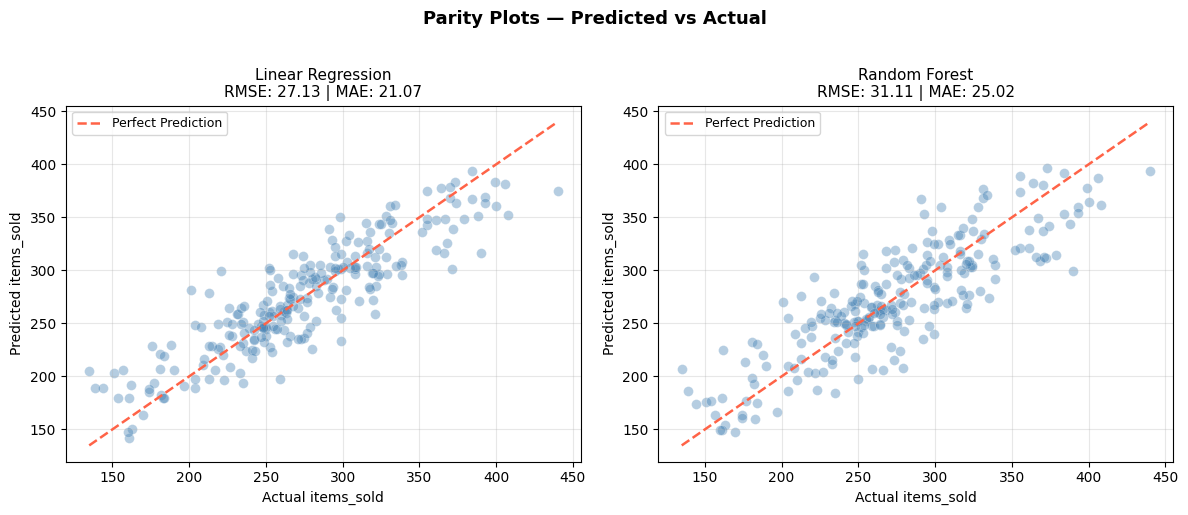

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, res) in zip(axes, results.items()):
    y_pred = res['y_pred']
    ax.scatter(y_test, y_pred, alpha=0.4, edgecolors='white',
               linewidths=0.3, s=50, color='steelblue')

    # Diagonal reference line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='tomato', linewidth=1.8, linestyle='--', label='Perfect Prediction')

    ax.set_title(f'{name}\nRMSE: {res["RMSE"]:.2f} | MAE: {res["MAE"]:.2f}', fontsize=11)
    ax.set_xlabel('Actual items_sold')
    ax.set_ylabel('Predicted items_sold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Parity Plots — Predicted vs Actual', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Top 5 Most Influential Features:
is_festival            0.1752
store_size_small       0.1706
location_type_urban    0.1072
day_of_week            0.0925
competition_density    0.0624
dtype: float64


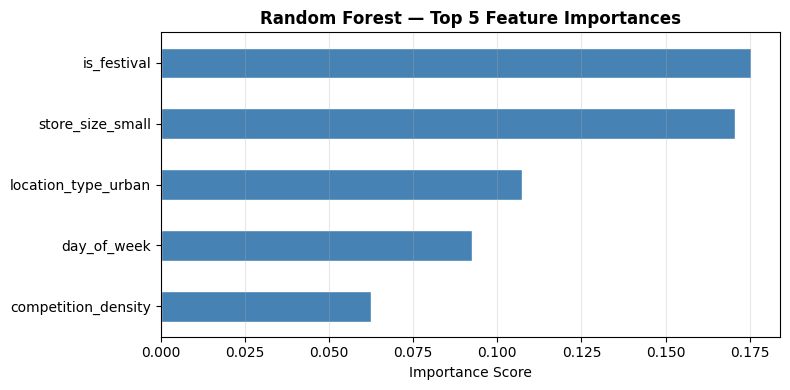

In [24]:
rf_pipeline = results['Random Forest']['pipeline']
rf_model    = rf_pipeline.named_steps['model']

# Get feature names after OHE
ohe_features = rf_pipeline.named_steps['preprocessor'] \
                           .named_transformers_['cat'] \
                           .get_feature_names_out(categorical_features)
all_features = list(ohe_features) + numerical_features

importances = pd.Series(rf_model.feature_importances_, index=all_features)
top5 = importances.sort_values(ascending=False).head(5)

print("Top 5 Most Influential Features:")
print(top5.round(4))

# Plot
top5.sort_values().plot(kind='barh', color='steelblue', edgecolor='white', figsize=(8, 4))
plt.title('Random Forest — Top 5 Feature Importances', fontweight='bold')
plt.xlabel('Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()